<a href="https://colab.research.google.com/github/armanboyaci/notebooks/blob/master/datascience_questions/q33_datascience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ### Assume you want to test whether a new feature increases signups to the site. How would you run this experiment? What statistical test(s) would you use?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.style.use('fivethirtyeight')

In [3]:
number_of_visitors = 100_000

In [4]:
signups = np.random.binomial(n=number_of_visitors, p=0.1, size=10_000)

<Axes: >

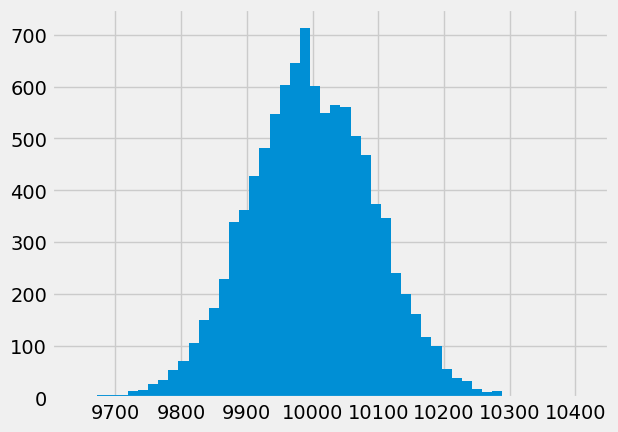

In [5]:
pd.Series(signups).hist(bins=50)

In [6]:
def log_likelihood(p, n, x):
    return x * np.log(p) + (n - x) * np.log(1 - p)

In [7]:
number_of_visitors, signups[0]

(100000, 9755)

<Axes: >

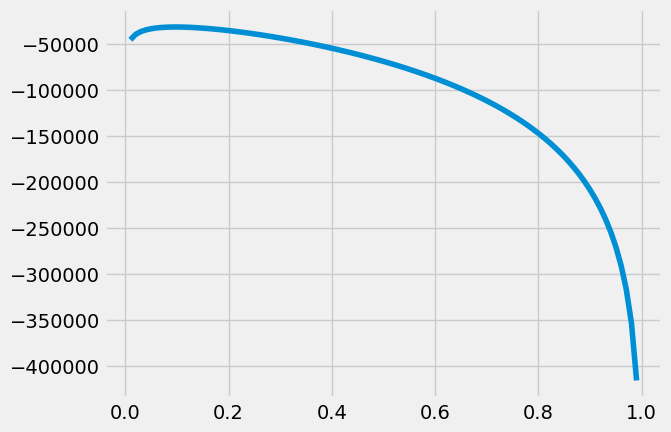

In [20]:
log_likelihood_p = pd.Series({p: log_likelihood(p=p, n=number_of_visitors, x=signups[0]) for p in np.arange(0.01,1,0.01)})


log_likelihood_p.plot()

In [21]:
# https://gregorygundersen.com/blog/2020/02/09/log-sum-exp/

In [22]:
log_likelihood_p.max()

-31969.97731769745

In [27]:
def logsumexp(x):
    c = x.max()
    return c + np.log(np.sum(np.exp(x - c)))

<Axes: >

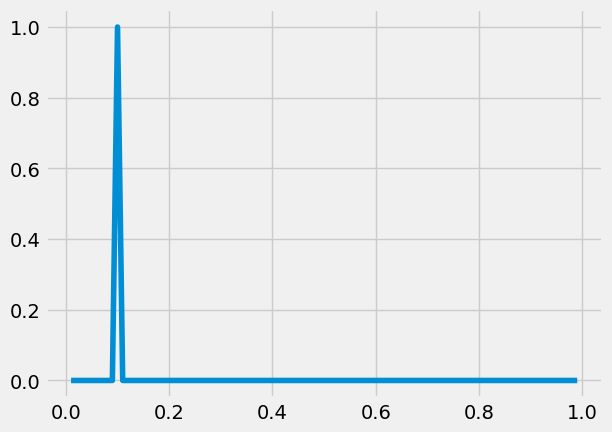

In [28]:
np.exp(log_likelihood_p - logsumexp(log_likelihood_p)).plot()